# FP-Cox Optimizer — SaDE v2 Test Suite

Tests the fixed and optimised `FPCoxOptimizer` (v2) on three datasets.

| Fix / Improvement | Description |
|---|---|
| FIX 1 | Repeated-power detection in `_generate_fp_features` |
| FIX 2 | BIC uses total `n`, not `n_events` |
| FIX 3 | Canonical cache key — swapped indices share one entry |
| FIX 4 | NaN / Inf guard after FP transform |
| IMP 5 | Combined objective: `BIC − γ·n·c-index` |
| IMP 6 | Warm-start population (seeds from common clinical FP shapes) |
| IMP 7 | `init_pop` injected into `_SaDE.run()` |
| IMP 8 | Strategy probability floor 0.01 → 0.05 |
| IMP 9 | `seed` exposed as parameter to `optimize()` |

## 0 · Dependencies
Run the cell below once if any package is missing.

In [1]:
# !pip install lifelines pandas numpy matplotlib

## 1 · SaDE Engine

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
import warnings
from collections import deque
from dataclasses import dataclass, field
from typing import List, Optional

warnings.filterwarnings('ignore')

# ── Power set ────────────────────────────────────────────────────────────────
POWER_SET = [None, -3, -2.5, -2, -1.5, -1, -0.5, -0.25,
              0, 0.25, 0.5, 1, 1.5, 2, 2.5, 3]
N_POWERS  = len(POWER_SET)   # 16, valid indices: 0..15


@dataclass
class _SaDEResult:
    x:       np.ndarray
    fun:     float
    nfev:    int
    ngen:    int
    history: List[float] = field(default_factory=list)


def _choose(n, k, excl, rng):
    cands = np.delete(np.arange(n), excl)
    return rng.choice(cands, size=k, replace=False)

def _s1(pop, F, t, b, rng):                          # DE/rand/1
    r1, r2, r3 = _choose(len(pop), 3, t, rng)
    return pop[r1] + F*(pop[r2] - pop[r3])

def _s2(pop, F, t, b, rng):                          # DE/rand-to-best/2
    r1, r2, r3, r4 = _choose(len(pop), 4, t, rng)
    return (pop[t] + F*(pop[b]  - pop[t])
                   + F*(pop[r1] - pop[r2])
                   + F*(pop[r3] - pop[r4]))

def _s3(pop, F, t, b, rng):                          # DE/current-to-rand/1
    r1, r2, r3 = _choose(len(pop), 3, t, rng)
    return pop[t] + F*(pop[r1] - pop[t]) + F*(pop[r2] - pop[r3])

def _s4(pop, F, t, b, rng):                          # DE/rand/2
    r1, r2, r3, r4, r5 = _choose(len(pop), 5, t, rng)
    return pop[r1] + F*(pop[r2] - pop[r3]) + F*(pop[r4] - pop[r5])

_STRATS = [_s1, _s2, _s3, _s4]
_NS     = len(_STRATS)


def _repair(v, lb, ub):
    v = np.round(v).astype(int)
    lo = v < lb;  v[lo] = lb[lo] + (lb[lo] - v[lo])
    hi = v > ub;  v[hi] = ub[hi] - (v[hi] - ub[hi])
    return np.clip(v, lb, ub)

def _cross(x, v, CR, rng):
    d = len(x)
    m = rng.random(d) < CR
    m[rng.integers(d)] = True
    return np.where(m, v, x)


class _SaDE:
    def __init__(self, func, bounds, pop_size=50, max_evals=50_000,
                 lp=50, seed=None, callback=None):
        self.func = func;  self.bounds = bounds;  self.dim = len(bounds)
        self.lb   = np.array([b[0] for b in bounds], dtype=int)
        self.ub   = np.array([b[1] for b in bounds], dtype=int)
        self.N    = pop_size;  self.maxev = max_evals;  self.lp = lp
        self.cb   = callback
        self.rng  = np.random.default_rng(seed)
        self.p    = np.ones(_NS) / _NS
        self.crm  = np.full(_NS, 0.5)
        self.ns   = [deque() for _ in range(_NS)]
        self.nf   = [deque() for _ in range(_NS)]
        self.crok = [deque() for _ in range(_NS)]

    def run(self, init_pop: Optional[np.ndarray] = None):
        if (init_pop is not None
                and init_pop.shape == (self.N, self.dim)):
            pop = np.clip(np.round(init_pop).astype(int), self.lb, self.ub)
        else:
            pop = np.column_stack([
                self.rng.integers(self.lb[d], self.ub[d]+1, self.N)
                for d in range(self.dim)
            ])

        fit  = np.array([self.func(pop[i]) for i in range(self.N)])
        nfev = self.N
        bi   = int(np.argmin(fit))
        hist = [float(fit[bi])]
        gen  = 0

        while nfev < self.maxev:
            gen += 1
            for i in range(self.N):
                if nfev >= self.maxev:
                    break
                k  = self.rng.choice(_NS, p=self.p)
                F  = float(np.clip(self.rng.standard_cauchy()*0.3 + 0.5, 1e-6, 2.0))
                CR = float(np.clip(self.rng.normal(self.crm[k], 0.1), 0.0, 1.0))
                v  = _STRATS[k](pop, F, i, bi, self.rng).astype(float)
                u  = _repair(_cross(pop[i].astype(float), v, CR, self.rng),
                              self.lb, self.ub)
                fu = self.func(u);  nfev += 1
                if fu <= fit[i]:
                    pop[i], fit[i] = u, fu
                    self.ns[k].append(1);  self.crok[k].append(CR)
                    if fu < fit[bi]:
                        bi = i
                else:
                    self.nf[k].append(1)

            if gen % self.lp == 0:
                self._upd_p();  self._upd_crm()

            hist.append(float(fit[bi]))
            if self.cb:
                self.cb(pop[bi], fit[bi], gen)

        return _SaDEResult(x=pop[bi].copy(), fun=float(fit[bi]),
                           nfev=nfev, ngen=gen, history=hist)

    def _upd_p(self):
        ns  = np.array([sum(q) for q in self.ns], dtype=float)
        nf  = np.array([sum(q) for q in self.nf], dtype=float)
        with np.errstate(divide='ignore', invalid='ignore'):
            r = np.where(ns + nf > 0, ns / (ns + nf), 0.0)
        tot = r.sum()
        if tot > 0:
            self.p = 0.05 + 0.95 * r / tot   # IMP 8: floor 0.01 → 0.05
            self.p /= self.p.sum()
        for k in range(_NS):
            while len(self.ns[k]) > self.lp: self.ns[k].popleft()
            while len(self.nf[k]) > self.lp: self.nf[k].popleft()

    def _upd_crm(self):
        for k in range(_NS):
            if self.crok[k]:
                self.crm[k] = float(np.median(list(self.crok[k])))
            while len(self.crok[k]) > self.lp: self.crok[k].popleft()


print('SaDE engine loaded.')

SaDE engine loaded.


## 2 · FPCoxOptimizer v2

In [3]:
class FPCoxOptimizer:
    """
    Selects optimal FP powers for a Cox PH model via SaDE.

    Parameters
    ----------
    df           : pandas DataFrame
    covariates   : list of continuous covariate column names
    duration_col : survival-time column
    event_col    : event-indicator column
    penalizer    : Cox ridge penalizer (default 0.01)
    gamma        : c-index weight  (default 0.0 = pure BIC)
                   objective = BIC − gamma × n × concordance_index
                   gamma=1 balances BIC and c-index on the same scale.
    """

    POWER_SET = [None, -3, -2.5, -2, -1.5, -1, -0.5, -0.25,
                  0, 0.25, 0.5, 1, 1.5, 2, 2.5, 3]
    N_POWERS  = len(POWER_SET)   # 16

    def __init__(self, df, covariates, duration_col, event_col,
                 penalizer=0.01, gamma=0.0):
        self.covariates   = covariates
        self.duration_col = duration_col
        self.event_col    = event_col
        self.penalizer    = penalizer
        self.gamma        = gamma

        self.df = self._preprocess_positive(df, covariates)

        self.evaluation_cache: dict = {}
        self.best_val           = np.inf
        self.history: list      = []
        self.best_powers: list  = []
        self.final_fp_model     = None
        self.traditional_model  = None

    # ── Preprocessing ─────────────────────────────────────────────────────────
    @staticmethod
    def _preprocess_positive(df, features):
        df = df.copy()
        for col in features:
            x = df[col].astype(float)
            df[col] = x - x.min() + 1e-5 if (x <= 0).any() else x
        return df

    # ── FIX 3: canonical cache key ────────────────────────────────────────────
    @staticmethod
    def _canonical_key(indices):
        """
        Sort each (idx_a, idx_b) pair so swapped indices share one cache entry.
        None (index 0) is always placed first.
        """
        key = list(indices)
        for i in range(0, len(key), 2):
            a, b = key[i], key[i+1]
            if b == 0 and a != 0:
                key[i], key[i+1] = 0, a
            elif a != 0 and b != 0:
                key[i], key[i+1] = min(a, b), max(a, b)
        return tuple(key)

    # ── FIX 1: generate_fp_features ───────────────────────────────────────────
    def _generate_fp_features(self, df, features, powers):
        """
        FIX 1: Repeated-power detection now uses explicit `if pa == pb`
        instead of `if idx==1 and p==p1`, which misfired on distinct powers.
        """
        transformed = {}
        for col, (p1, p2) in zip(features, powers):
            x      = df[col].values.astype(float)
            active = sorted([p for p in (p1, p2) if p is not None])

            if not active:
                continue

            if len(active) == 1:                         # FP1
                p = active[0]
                z = np.log(x) if p == 0 else np.power(x, p)
                transformed[f'{col}_fp_{p}'] = z

            else:                                        # FP2
                pa, pb = active[0], active[1]
                za = np.log(x) if pa == 0 else np.power(x, pa)
                transformed[f'{col}_fp1_{pa}'] = za
                if pa == pb:                             # repeated: x^p · ln x
                    transformed[f'{col}_fp2_rep_{pb}'] = za * np.log(x)
                else:
                    zb = np.log(x) if pb == 0 else np.power(x, pb)
                    transformed[f'{col}_fp2_{pb}'] = zb

        return pd.DataFrame(transformed, index=df.index)

    # ── FIX 2 + FIX 3 + FIX 4 + IMP 5: objective ────────────────────────────
    def _objective_function(self, x):
        key = self._canonical_key(x)                    # FIX 3
        if key in self.evaluation_cache:
            return self.evaluation_cache[key]

        powers = [
            (self.POWER_SET[key[2*i]], self.POWER_SET[key[2*i+1]])
            for i in range(len(self.covariates))
        ]

        df_fp = self._generate_fp_features(self.df, self.covariates, powers)
        if df_fp.shape[1] == 0:
            self.evaluation_cache[key] = 1e10
            return 1e10

        if not np.isfinite(df_fp.values).all():         # FIX 4
            self.evaluation_cache[key] = 1e10
            return 1e10

        df_model = df_fp.copy()
        df_model[self.duration_col] = self.df[self.duration_col].values
        df_model[self.event_col]    = self.df[self.event_col].values

        cph = CoxPHFitter(penalizer=self.penalizer)
        try:
            cph.fit(df_model, duration_col=self.duration_col,
                    event_col=self.event_col, show_progress=False)
            n   = len(self.df)                          # FIX 2: total n
            k   = len(cph.params_)
            bic = -2 * cph.log_likelihood_ + k * np.log(n)
            ci  = cph.concordance_index_
            val = bic - self.gamma * n * ci             # IMP 5
        except Exception:
            val = 1e10

        self.evaluation_cache[key] = val
        if val < self.best_val:
            self.best_val = val
        return val

    # ── IMP 6: warm-start population ──────────────────────────────────────────
    def _warm_start_pop(self, pop_size: int, rng: np.random.Generator):
        dim  = 2 * len(self.covariates)
        pop  = rng.integers(0, self.N_POWERS, size=(pop_size, dim))
        NA, LIN, SQ, LG, Q = 0, 11, 10, 8, 13
        seeds = [
            np.tile([LIN, NA], len(self.covariates)),   # all FP1 linear
            np.tile([SQ,  NA], len(self.covariates)),   # all FP1 sqrt
            np.tile([LG,  NA], len(self.covariates)),   # all FP1 log
            np.tile([LIN, SQ], len(self.covariates)),   # all FP2(1, 0.5)
            np.tile([LIN, Q],  len(self.covariates)),   # all FP2(1, 2)
        ]
        for row, seed in enumerate(seeds[:min(len(seeds), pop_size)]):
            pop[row] = seed
        return pop

    def _callback(self, best_x, best_f, gen):
        self.history.append(self.best_val)

    # ── Main optimisation ─────────────────────────────────────────────────────
    def optimize(self, maxiter=50, popsize=15, seed=42):   # IMP 9
        """
        Parameters
        ----------
        maxiter : maximum generations
        popsize : pop size multiplier per dimension
        seed    : RNG seed (IMP 9: was hard-coded to 42 in v1)
        """
        dim       = 2 * len(self.covariates)
        bounds    = [(0, self.N_POWERS - 1)] * dim
        pop_size  = popsize * dim
        max_evals = pop_size * maxiter

        print(f'Starting SaDE Optimisation  (gamma = {self.gamma})')
        print(f'  Features   : {len(self.covariates)}')
        print(f'  Population : {pop_size}  |  Generations : {maxiter}'
              f'  |  Budget : {max_evals} evals')
        print('  Objective  : ' +
              (f'BIC − {self.gamma} × n × c-index'
               if self.gamma > 0 else 'BIC only'))

        rng      = np.random.default_rng(seed)
        init_pop = self._warm_start_pop(pop_size, rng)    # IMP 6

        optimizer = _SaDE(
            func      = self._objective_function,
            bounds    = bounds,
            pop_size  = pop_size,
            max_evals = max_evals,
            lp        = 50,
            seed      = seed,
            callback  = self._callback,
        )
        result = optimizer.run(init_pop=init_pop)         # IMP 7

        best_indices = result.x
        print('\n--- Optimal Power Selection (SaDE v2) ---')
        for i in range(len(self.covariates)):
            p1 = self.POWER_SET[best_indices[2*i]]
            p2 = self.POWER_SET[best_indices[2*i+1]]
            self.best_powers.append((p1, p2))
            print(f'  {self.covariates[i]:<22}: p1 = {str(p1):<7} p2 = {p2}')

        print(f'\n  Best objective : {result.fun:.4f}')
        print(f'  Generations    : {result.ngen}')
        print(f'  Evaluations    : {result.nfev}'
              f'  (cache hits: {result.nfev - len(self.evaluation_cache)})')

        self._plot_convergence()
        self._fit_final_models()

    # ── Convergence plot ──────────────────────────────────────────────────────
    def _plot_convergence(self):
        plt.figure(figsize=(10, 5))
        plt.plot(range(1, len(self.history)+1), self.history,
                 marker='o', markersize=3, linestyle='-', color='steelblue')
        plt.title('SaDE v2 — Convergence')
        plt.xlabel('Generation')
        plt.ylabel('BIC − γ·n·c-index' if self.gamma > 0 else 'BIC')
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()

    # ── Final model comparison ────────────────────────────────────────────────
    def _fit_final_models(self):
        print('\n' + '='*65)
        print('FINAL MODEL COMPARISON')
        print('='*65)

        # Traditional Cox
        df_trad = self.df[
            self.covariates + [self.duration_col, self.event_col]
        ].copy()
        self.traditional_model = CoxPHFitter(penalizer=self.penalizer)
        self.traditional_model.fit(df_trad, duration_col=self.duration_col,
                                   event_col=self.event_col, show_progress=False)

        # FP Cox
        df_fp = self._generate_fp_features(
            self.df, self.covariates, self.best_powers)
        df_fp[self.duration_col] = self.df[self.duration_col].values
        df_fp[self.event_col]    = self.df[self.event_col].values
        self.final_fp_model = CoxPHFitter(penalizer=self.penalizer)
        self.final_fp_model.fit(df_fp, duration_col=self.duration_col,
                                event_col=self.event_col, show_progress=False)

        # BIC (FIX 2: uses total n)
        n    = len(self.df)
        k_t  = len(self.traditional_model.params_)
        k_fp = len(self.final_fp_model.params_)
        bic_t  = -2*self.traditional_model.log_likelihood_ + k_t  * np.log(n)
        bic_fp = -2*self.final_fp_model.log_likelihood_    + k_fp * np.log(n)
        ci_t   = self.traditional_model.concordance_index_
        ci_fp  = self.final_fp_model.concordance_index_

        W = 22
        hdr = f"\n{'Metric':<25} | {'Traditional Cox':>{W}} | {'FP Cox (SaDE v2)':>{W}}"
        print(hdr)
        print('-' * len(hdr))
        print(f"{'Concordance index':<25} | {ci_t:>{W}.4f} | {ci_fp:>{W}.4f}")
        print(f"{'BIC (n-based)':<25} | {bic_t:>{W}.2f} | {bic_fp:>{W}.2f}")
        print(f"{'Log-likelihood':<25} | {self.traditional_model.log_likelihood_:>{W}.4f}"
              f" | {self.final_fp_model.log_likelihood_:>{W}.4f}")
        print(f"{'Parameters (k)':<25} | {k_t:>{W}d} | {k_fp:>{W}d}")


print('FPCoxOptimizer v2 loaded.')

FPCoxOptimizer v2 loaded.


---
## 3 · Dataset 1 — Simulated Data

Single covariate (`Age`). Quick sanity check.  
Update the path below if needed.

Starting SaDE Optimisation  (gamma = 0.0)
  Features   : 1
  Population : 80  |  Generations : 30  |  Budget : 2400 evals
  Objective  : BIC only

--- Optimal Power Selection (SaDE v2) ---
  Age                   : p1 = -2      p2 = None

  Best objective : 1198.7942
  Generations    : 29
  Evaluations    : 2400  (cache hits: 2265)


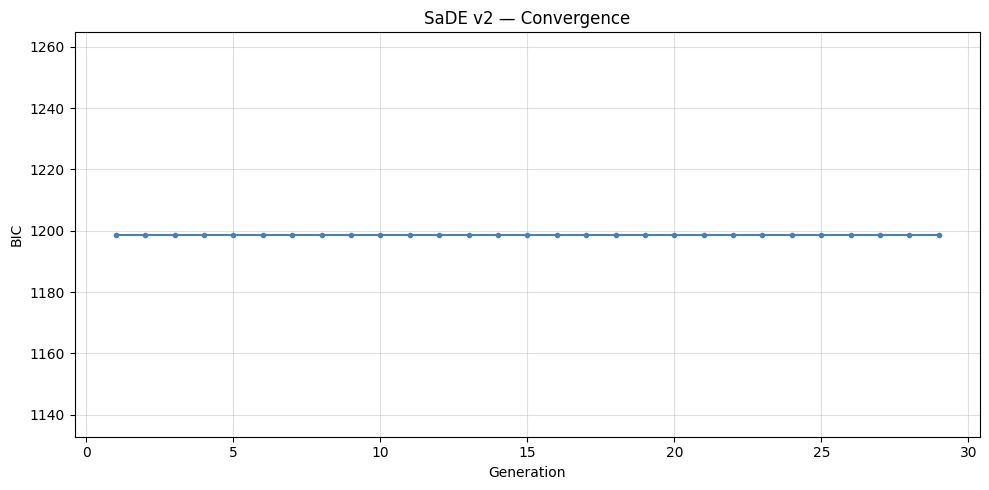


FINAL MODEL COMPARISON

Metric                    |        Traditional Cox |       FP Cox (SaDE v2)
----------------------------------------------------------------------------
Concordance index         |                 0.6413 |                 0.6413
BIC (n-based)             |                1204.41 |                1198.79
Log-likelihood            |              -599.5572 |              -596.7479
Parameters (k)            |                      1 |                      1


In [4]:
sd_df = pd.read_csv(
    'C:/Users/RASHMIKA/Desktop/4th/research/New folder/'
    'CSC-461-8.0-Research-Project/data/preprocess-data/preprocess_simulated_data.csv'
)

np.random.seed(42)

optimizer_sd = FPCoxOptimizer(
    df           = sd_df,
    covariates   = ['Age'],
    duration_col = 'Time',
    event_col    = 'Event',
    gamma        = 0.0,     # pure BIC — change to 1.0 to also optimise c-index
)
optimizer_sd.optimize(maxiter=30, popsize=40, seed=42)

In [5]:
# Detailed lifelines summary for the FP Cox model
print('FP Cox model summary (Dataset 1 — Simulated):')
optimizer_sd.final_fp_model.print_summary()

FP Cox model summary (Dataset 1 — Simulated):


<lifelines.CoxPHFitter: fitted with 200 total observations, 59 right-censored observations>
             duration col = 'Time'
                event col = 'Event'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 200
number of events observed = 141
   partial log-likelihood = -596.75
         time fit was run = 2026-03-15 13:49:36 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
Age_fp_-2 -2594.04      0.00    537.98        -3648.45        -1539.62                0.00                 NaN

           cmp to     z      p  -log2(p)
covariate                               
Age_fp_-2    0.00 -4.82 <0.005     19.42
---
Concordance = 0.64
Partial AIC = 1195.50
log-likelihood ratio test = 26.85 on 1 df
-log2(p) of ll-ratio test = 22.12

### 3b · Dataset 1 — combined objective (gamma = 1)

Starting SaDE Optimisation  (gamma = 1.0)
  Features   : 1
  Population : 80  |  Generations : 30  |  Budget : 2400 evals
  Objective  : BIC − 1.0 × n × c-index

--- Optimal Power Selection (SaDE v2) ---
  Age                   : p1 = None    p2 = -2

  Best objective : 1070.5347
  Generations    : 29
  Evaluations    : 2400  (cache hits: 2264)


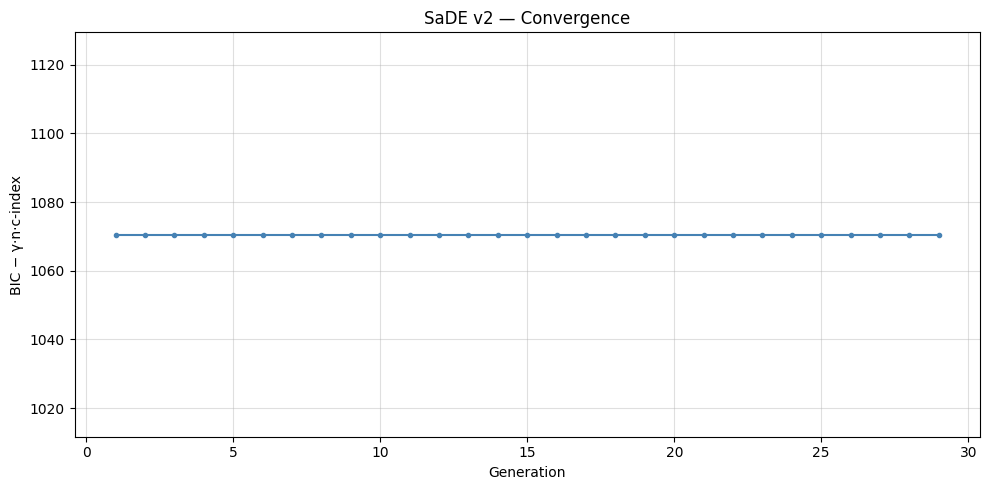


FINAL MODEL COMPARISON

Metric                    |        Traditional Cox |       FP Cox (SaDE v2)
----------------------------------------------------------------------------
Concordance index         |                 0.6413 |                 0.6413
BIC (n-based)             |                1204.41 |                1198.79
Log-likelihood            |              -599.5572 |              -596.7479
Parameters (k)            |                      1 |                      1


In [6]:
optimizer_sd_ci = FPCoxOptimizer(
    df           = sd_df,
    covariates   = ['Age'],
    duration_col = 'Time',
    event_col    = 'Event',
    gamma        = 1.0,     # BIC − n × c-index
)
optimizer_sd_ci.optimize(maxiter=30, popsize=40, seed=42)

---
## 4 · Dataset 2 — Haberman

Two covariates: `PatientAge`, `LogNodes`.

Starting SaDE Optimisation  (gamma = 0.0)
  Features   : 2
  Population : 160  |  Generations : 30  |  Budget : 4800 evals
  Objective  : BIC only

--- Optimal Power Selection (SaDE v2) ---
  PatientAge            : p1 = None    p2 = None
  LogNodes              : p1 = None    p2 = 0.5

  Best objective : 766.6718
  Generations    : 29
  Evaluations    : 4800  (cache hits: 1928)


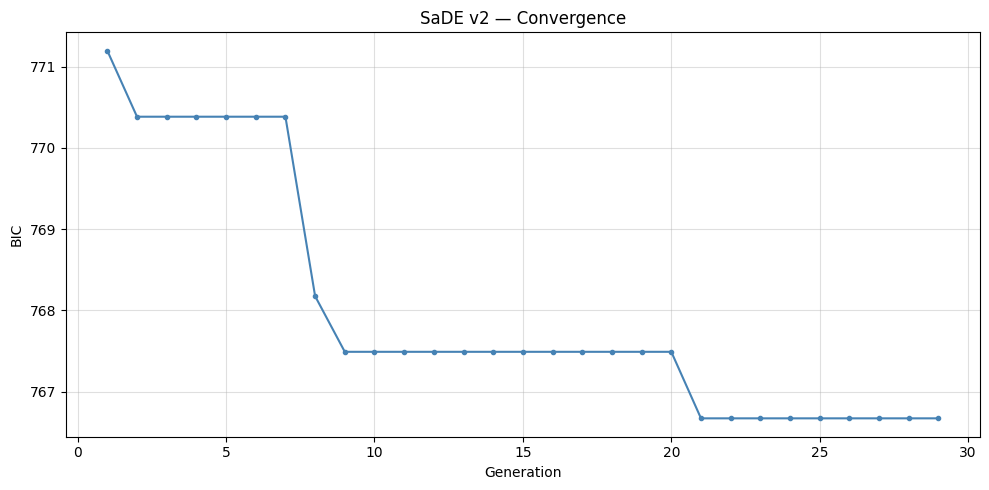


FINAL MODEL COMPARISON

Metric                    |        Traditional Cox |       FP Cox (SaDE v2)
----------------------------------------------------------------------------
Concordance index         |                 0.6682 |                 0.6589
BIC (n-based)             |                 772.23 |                 766.67
Log-likelihood            |              -380.3925 |              -380.4758
Parameters (k)            |                      2 |                      1


In [7]:
hm_df = pd.read_csv(
    'C:/Users/RASHMIKA/Desktop/4th/research/New folder/'
    'CSC-461-8.0-Research-Project/data/preprocess-data/preprocess_haberman.csv'
)

np.random.seed(42)

optimizer_hm = FPCoxOptimizer(
    df           = hm_df,
    covariates   = ['PatientAge', 'LogNodes'],
    duration_col = 'PatientYearOperation',
    event_col    = 'SurvivalStatus',
    gamma        = 0.0,
)
optimizer_hm.optimize(maxiter=30, popsize=40, seed=42)

In [8]:
print('FP Cox model summary (Dataset 2 — Haberman):')
optimizer_hm.final_fp_model.print_summary()

FP Cox model summary (Dataset 2 — Haberman):


<lifelines.CoxPHFitter: fitted with 305 total observations, 224 right-censored observations>
             duration col = 'PatientYearOperation'
                event col = 'SurvivalStatus'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 305
number of events observed = 81
   partial log-likelihood = -380.48
         time fit was run = 2026-03-15 13:54:02 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
LogNodes_fp_0.5  0.79      2.21      0.17            0.46            1.12                1.59                3.08

                 cmp to    z      p  -log2(p)
covariate                                    
LogNodes_fp_0.5    0.00 4.69 <0.005     18.47
---
Concordance = 0.66
Partial AIC = 762.95
log-likelihood ratio test = 23.69 on 1 df
-log2(p) of ll-ratio test = 19.75

### 4b · Dataset 2 — combined objective (gamma = 1)

Starting SaDE Optimisation  (gamma = 1.0)
  Features   : 2
  Population : 160  |  Generations : 30  |  Budget : 4800 evals
  Objective  : BIC − 1.0 × n × c-index

--- Optimal Power Selection (SaDE v2) ---
  PatientAge            : p1 = None    p2 = -3
  LogNodes              : p1 = 0.5     p2 = None

  Best objective : 564.3170
  Generations    : 29
  Evaluations    : 4800  (cache hits: 1795)


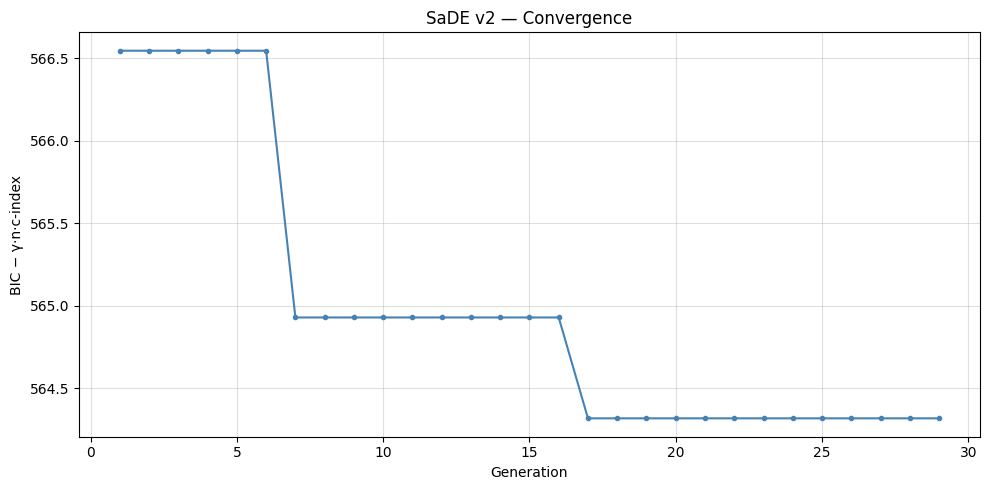


FINAL MODEL COMPARISON

Metric                    |        Traditional Cox |       FP Cox (SaDE v2)
----------------------------------------------------------------------------
Concordance index         |                 0.6682 |                 0.6751
BIC (n-based)             |                 772.23 |                 770.22
Log-likelihood            |              -380.3925 |              -379.3902
Parameters (k)            |                      2 |                      2


In [9]:
optimizer_hm_ci = FPCoxOptimizer(
    df           = hm_df,
    covariates   = ['PatientAge', 'LogNodes'],
    duration_col = 'PatientYearOperation',
    event_col    = 'SurvivalStatus',
    gamma        = 1.0,
)
optimizer_hm_ci.optimize(maxiter=30, popsize=40, seed=42)

---
## 5 · Dataset 3 — GBSG

Five covariates: `log_pgr`, `log_nodes`, `age`, `meno`, `size`.

Starting SaDE Optimisation  (gamma = 0.0)
  Features   : 5
  Population : 300  |  Generations : 20  |  Budget : 6000 evals
  Objective  : BIC only

--- Optimal Power Selection (SaDE v2) ---
  log_pgr               : p1 = 3       p2 = 1
  log_nodes             : p1 = None    p2 = 1
  age                   : p1 = -3      p2 = 0
  meno                  : p1 = 0       p2 = None
  size                  : p1 = None    p2 = -0.25

  Best objective : 3484.2472
  Generations    : 19
  Evaluations    : 6000  (cache hits: 515)


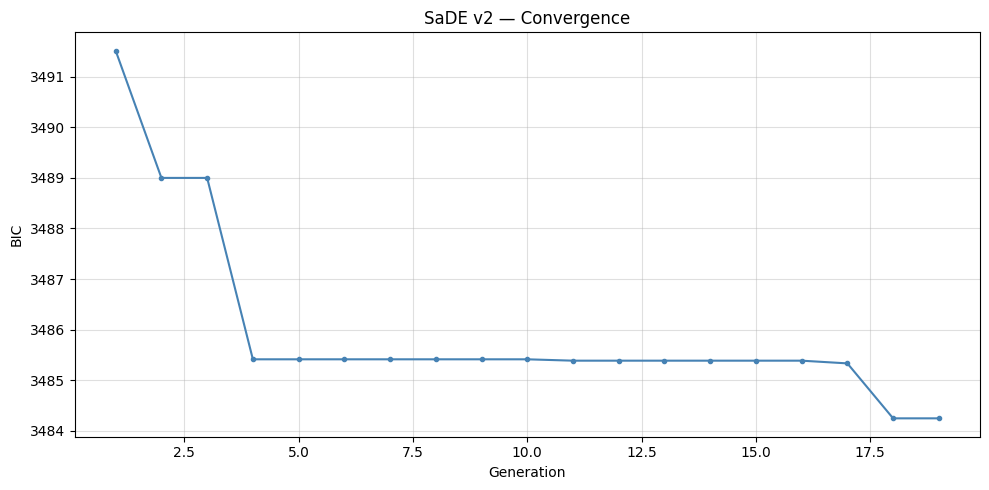


FINAL MODEL COMPARISON

Metric                    |        Traditional Cox |       FP Cox (SaDE v2)
----------------------------------------------------------------------------
Concordance index         |                 0.6895 |                 0.7021
BIC (n-based)             |                3491.51 |                3484.25
Log-likelihood            |             -1729.4297 |             -1719.2655
Parameters (k)            |                      5 |                      7


In [10]:
gb_df = pd.read_csv(
    'C:/Users/RASHMIKA/Desktop/4th/research/New folder/'
    'CSC-461-8.0-Research-Project/data/preprocess-data/preprocess_gbsg.csv'
)

np.random.seed(42)

optimizer_gb = FPCoxOptimizer(
    df           = gb_df,
    covariates   = ['log_pgr', 'log_nodes', 'age', 'meno', 'size'],
    duration_col = 'rfstime',
    event_col    = 'status',
    gamma        = 0.0,
)
optimizer_gb.optimize(maxiter=20, popsize=30, seed=42)

In [11]:
print('FP Cox model summary (Dataset 3 — GBSG):')
optimizer_gb.final_fp_model.print_summary()

FP Cox model summary (Dataset 3 — GBSG):


<lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>
             duration col = 'rfstime'
                event col = 'status'
                penalizer = 0.01
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 686
number of events observed = 299
   partial log-likelihood = -1719.27
         time fit was run = 2026-03-15 14:08:33 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
log_pgr_fp1_1     -0.11      0.89      0.06           -0.23           -0.00                0.80                1.00
log_pgr_fp2_3     -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
log_nodes_fp_1     0.60      1.83      0.08            0.44            0.76                1.56                2.14
age_fp1_-3     50796.30       inf  10644.33        29933.80        71658.79                 NaN                 inf
age_fp2_0          1.13      3.10      0.61           -0.07            2.34                0.93               10.34
meno_fp_0          0.01      1.01      0.02           -0.02            0.04                0.98                1.04
size_fp_-0.25     -2.29      0.10      1.21           -4.67            0.09                0.01                1.09

                cmp to     z      p  -log2(p)
covariate                                    
log_pgr_fp1_1     0.00 -1.98   0.05      4.40
log_pgr_fp2_3     0.00 -1.48   0.14      2.85
log_nodes_fp_1    0.00  7.42 <0.005     43.00
age_fp1_-3        0.00  4.77 <0.005     19.07
age_fp2_0         0.00  1.84   0.07      3.94
meno_fp_0         0.00  0.64   0.53      0.93
size_fp_-0.25     0.00 -1.89   0.06      4.08
---
Concordance = 0.70
Partial AIC = 3452.53
log-likelihood ratio test = 137.68 on 7 df
-log2(p) of ll-ratio test = 85.73

### 5b · Dataset 3 — combined objective (gamma = 1)

Starting SaDE Optimisation  (gamma = 1.0)
  Features   : 5
  Population : 300  |  Generations : 20  |  Budget : 6000 evals
  Objective  : BIC − 1.0 × n × c-index

--- Optimal Power Selection (SaDE v2) ---
  log_pgr               : p1 = None    p2 = 2
  log_nodes             : p1 = -2.5    p2 = 1
  age                   : p1 = 0.25    p2 = -3
  meno                  : p1 = None    p2 = 0
  size                  : p1 = -1.5    p2 = None

  Best objective : 3001.0916
  Generations    : 19
  Evaluations    : 6000  (cache hits: 514)


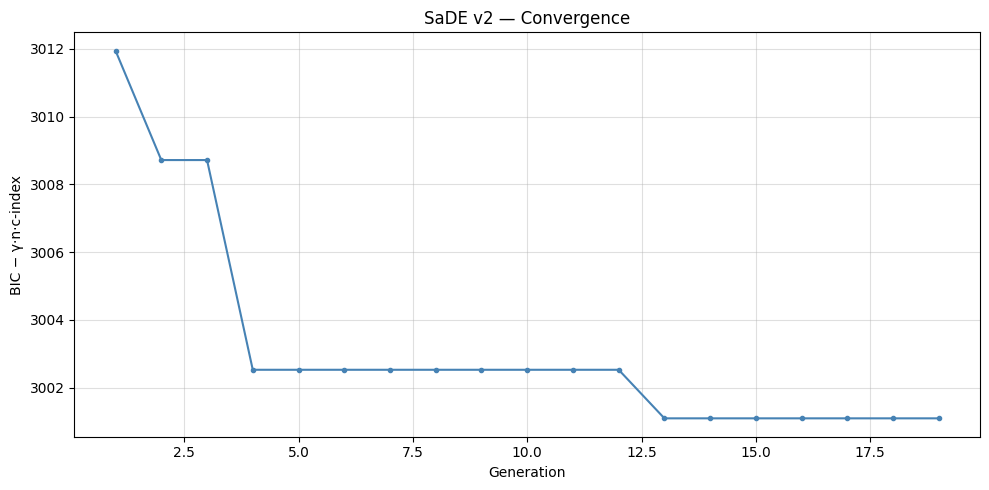


FINAL MODEL COMPARISON

Metric                    |        Traditional Cox |       FP Cox (SaDE v2)
----------------------------------------------------------------------------
Concordance index         |                 0.6895 |                 0.7034
BIC (n-based)             |                3491.51 |                3483.65
Log-likelihood            |             -1729.4297 |             -1718.9685
Parameters (k)            |                      5 |                      7


In [12]:
optimizer_gb_ci = FPCoxOptimizer(
    df           = gb_df,
    covariates   = ['log_pgr', 'log_nodes', 'age', 'meno', 'size'],
    duration_col = 'rfstime',
    event_col    = 'status',
    gamma        = 1.0,
)
optimizer_gb_ci.optimize(maxiter=20, popsize=30, seed=42)

---
## 6 · Cross-dataset Summary

Collect concordance index and BIC for all six runs (3 datasets × 2 gamma values).

In [13]:
def extract_metrics(opt):
    """Return (c-index trad, c-index FP, BIC trad, BIC FP, k trad, k FP)."""
    n    = len(opt.df)
    k_t  = len(opt.traditional_model.params_)
    k_fp = len(opt.final_fp_model.params_)
    bic_t  = -2*opt.traditional_model.log_likelihood_ + k_t  * np.log(n)
    bic_fp = -2*opt.final_fp_model.log_likelihood_    + k_fp * np.log(n)
    return {
        'C-index (trad)' : round(opt.traditional_model.concordance_index_, 4),
        'C-index (FP)'   : round(opt.final_fp_model.concordance_index_,    4),
        'BIC (trad)'     : round(bic_t,  2),
        'BIC (FP)'       : round(bic_fp, 2),
        'k (trad)'       : k_t,
        'k (FP)'         : k_fp,
    }

rows = [
    ('Simulated  γ=0', extract_metrics(optimizer_sd)),
    ('Simulated  γ=1', extract_metrics(optimizer_sd_ci)),
    ('Haberman   γ=0', extract_metrics(optimizer_hm)),
    ('Haberman   γ=1', extract_metrics(optimizer_hm_ci)),
    ('GBSG       γ=0', extract_metrics(optimizer_gb)),
    ('GBSG       γ=1', extract_metrics(optimizer_gb_ci)),
]

summary_df = pd.DataFrame(
    {name: metrics for name, metrics in rows}
).T

print('\n=== Cross-dataset Summary ===')
print(summary_df.to_string())


=== Cross-dataset Summary ===
                C-index (trad)  C-index (FP)  BIC (trad)  BIC (FP)  k (trad)  k (FP)
Simulated  γ=0          0.6413        0.6413     1204.41   1198.79       1.0     1.0
Simulated  γ=1          0.6413        0.6413     1204.41   1198.79       1.0     1.0
Haberman   γ=0          0.6682        0.6589      772.23    766.67       2.0     1.0
Haberman   γ=1          0.6682        0.6751      772.23    770.22       2.0     2.0
GBSG       γ=0          0.6895        0.7021     3491.51   3484.25       5.0     7.0
GBSG       γ=1          0.6895        0.7034     3491.51   3483.65       5.0     7.0


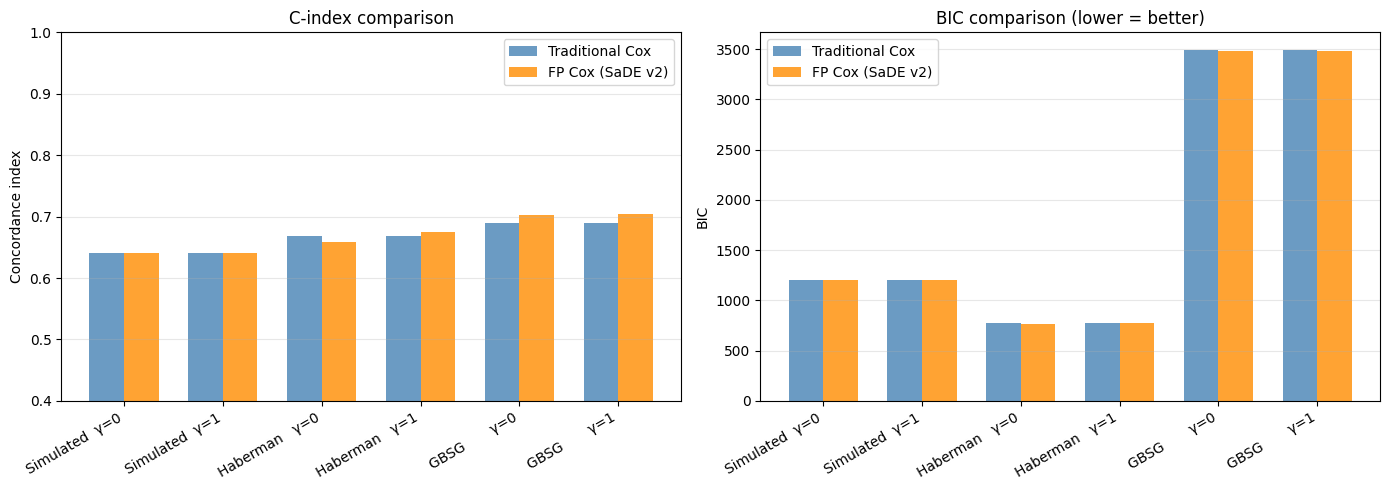

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels   = [r[0] for r in rows]
c_trad   = [r[1]['C-index (trad)'] for r in rows]
c_fp     = [r[1]['C-index (FP)']   for r in rows]
bic_trad = [r[1]['BIC (trad)']     for r in rows]
bic_fp   = [r[1]['BIC (FP)']       for r in rows]

x = np.arange(len(labels))
w = 0.35

axes[0].bar(x - w/2, c_trad, w, label='Traditional Cox', color='steelblue',  alpha=0.8)
axes[0].bar(x + w/2, c_fp,   w, label='FP Cox (SaDE v2)', color='darkorange', alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=30, ha='right')
axes[0].set_ylabel('Concordance index');  axes[0].set_title('C-index comparison')
axes[0].legend();  axes[0].set_ylim(0.4, 1.0);  axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x - w/2, bic_trad, w, label='Traditional Cox', color='steelblue',  alpha=0.8)
axes[1].bar(x + w/2, bic_fp,   w, label='FP Cox (SaDE v2)', color='darkorange', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=30, ha='right')
axes[1].set_ylabel('BIC');  axes[1].set_title('BIC comparison (lower = better)')
axes[1].legend();  axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()